**Project Code:** P001-MVB
**Stage:** 06_MVB_Evaluation
**Notebook Version:** v1.0
**Author:** Abubakar Amidu
**Programme:** 3MTT DeepTech Cohort 2 — DS/ML Mentorship
**Last Updated:** 26 July 2026

---

# MVB-06 — Evaluation

**Project:** P001-MVB — Explainable and Responsible AI for Differentiating Bacterial and Viral Meningitis: A Clinical Decision Support System

## Purpose

Comprehensively evaluate all six model variants from Stage 05, prioritizing recall for the Bacterial class per the project's clinical objective, and select the final model to carry into Stage 07 (Explainability).

## Inputs

- `Models/` — 6 trained models and 2 scalers (Stage 05 output)
- `MVB-05-results/MVB-05-baseline-metrics.csv`

## Outputs

- Figures: `MVB-06-figures/` (ROC curves, precision-recall curves, confusion matrices)
- Detailed metrics table: `MVB-06-results/MVB-06-detailed-metrics.csv`
- False-negative case analysis: `MVB-06-results/MVB-06-false-negatives.csv`
- This notebook
- Updated documentation

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imports
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc,
                              precision_recall_curve, recall_score, precision_score)

np.random.seed(42)

In [ ]:

# Load trained models and scalers from Stage 05
def load_model(name):
    with open(f"../05_MVB_Model-Training/Models/{name}", "rb") as f:
        return pickle.load(f)

lr_a = load_model("MVB-05-lr-A.pkl")
rf_a = load_model("MVB-05-rf-A.pkl")
xgb_a = load_model("MVB-05-xgb-A.pkl")
lr_b = load_model("MVB-05-lr-B.pkl")
rf_b = load_model("MVB-05-rf-B.pkl")
xgb_b = load_model("MVB-05-xgb-B.pkl")
scaler_a = load_model("MVB-05-scaler-A.pkl")
scaler_b = load_model("MVB-05-scaler-B.pkl")

print("All 6 models and 2 scalers loaded.")

All 6 models and 2 scalers loaded.


In [ ]:

# Rebuild the same train/test split used in Stage 05 (same seed, same source data)
from sklearn.model_selection import train_test_split

df_a = pd.read_csv("../04_MVB_Feature-Engineering/MVB-04-results/MVB-04-feature-set-A-full.csv")
df_b = pd.read_csv("../04_MVB_Feature-Engineering/MVB-04-results/MVB-04-feature-set-B-restricted.csv")

feature_set_a_cols = [c for c in df_a.columns if c != "Diagnosis"]
feature_set_b_cols = [c for c in df_b.columns if c != "Diagnosis"]

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    df_a[feature_set_a_cols], df_a["Diagnosis"], test_size=0.2, stratify=df_a["Diagnosis"], random_state=42)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    df_b[feature_set_b_cols], df_b["Diagnosis"], test_size=0.2, stratify=df_b["Diagnosis"], random_state=42)

X_test_a_scaled = scaler_a.transform(X_test_a)
X_test_b_scaled = scaler_b.transform(X_test_b)

print("Test sets reconstructed:", X_test_a.shape, X_test_b.shape)

Test sets reconstructed: (227, 10) (227, 9)


## ROC Curve Analysis

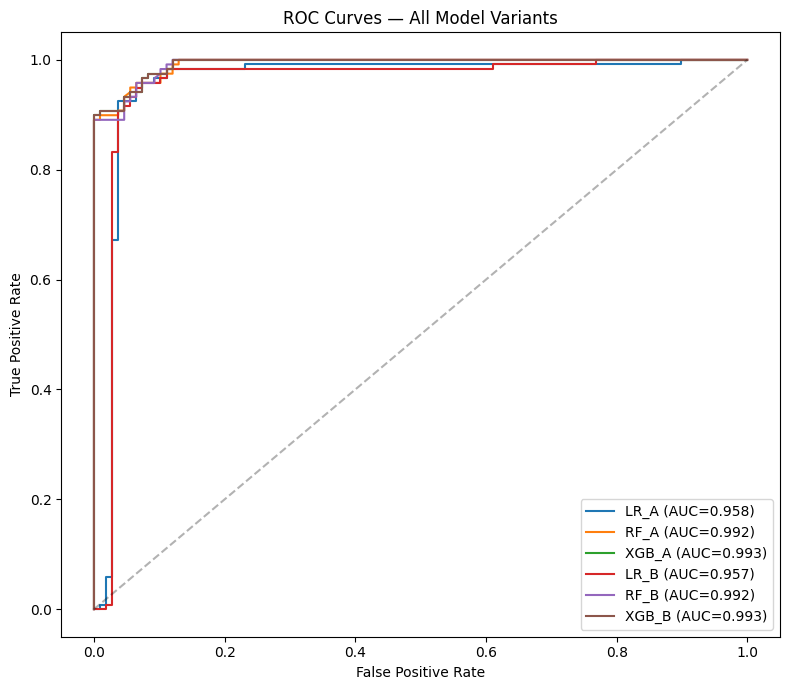

In [ ]:
# Plot ROC curves for all 6 model variants
model_configs = [
    ("LR_A", lr_a, X_test_a_scaled, y_test_a), ("RF_A", rf_a, X_test_a, y_test_a), ("XGB_A", xgb_a, X_test_a, y_test_a),
    ("LR_B", lr_b, X_test_b_scaled, y_test_b), ("RF_B", rf_b, X_test_b, y_test_b), ("XGB_B", xgb_b, X_test_b, y_test_b),
]

fig, ax = plt.subplots(figsize=(8,7))
for name, model, X_test, y_test in model_configs:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
ax.plot([0,1], [0,1], "k--", alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Model Variants")
ax.legend()
plt.tight_layout()
plt.savefig("MVB-06-figures/fig-01-roc-curves.png", dpi=150)
plt.show()

## Precision-Recall Curve Analysis

Precision-recall curves are especially important here, given the project's priority on Bacterial recall over aggregate accuracy.

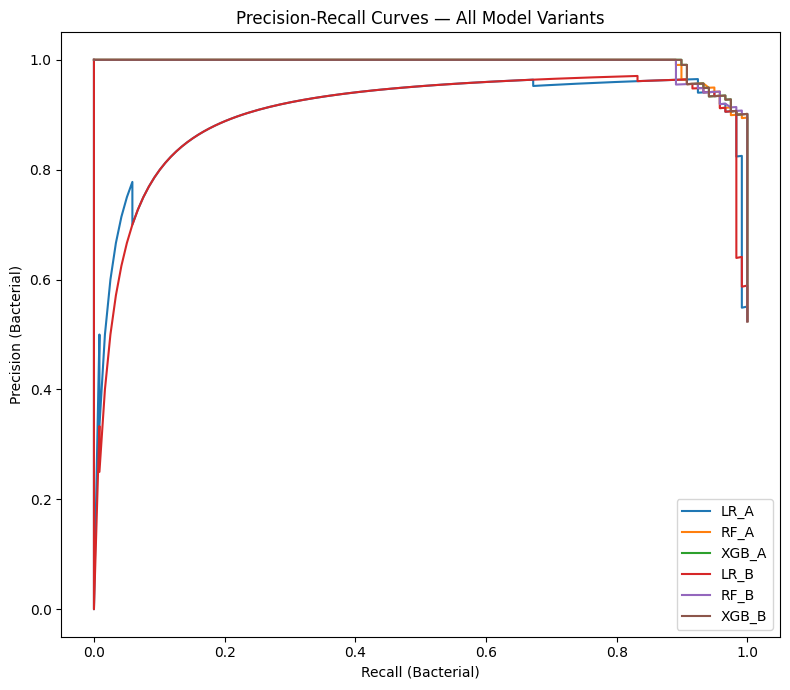

In [ ]:

# Plot precision-recall curves for all 6 model variants
fig, ax = plt.subplots(figsize=(8,7))
for name, model, X_test, y_test in model_configs:
    proba = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax.plot(rec, prec, label=name)
ax.set_xlabel("Recall (Bacterial)")
ax.set_ylabel("Precision (Bacterial)")
ax.set_title("Precision-Recall Curves — All Model Variants")
ax.legend()
plt.tight_layout()
plt.savefig("MVB-06-figures/fig-02-precision-recall-curves.png", dpi=150)
plt.show()

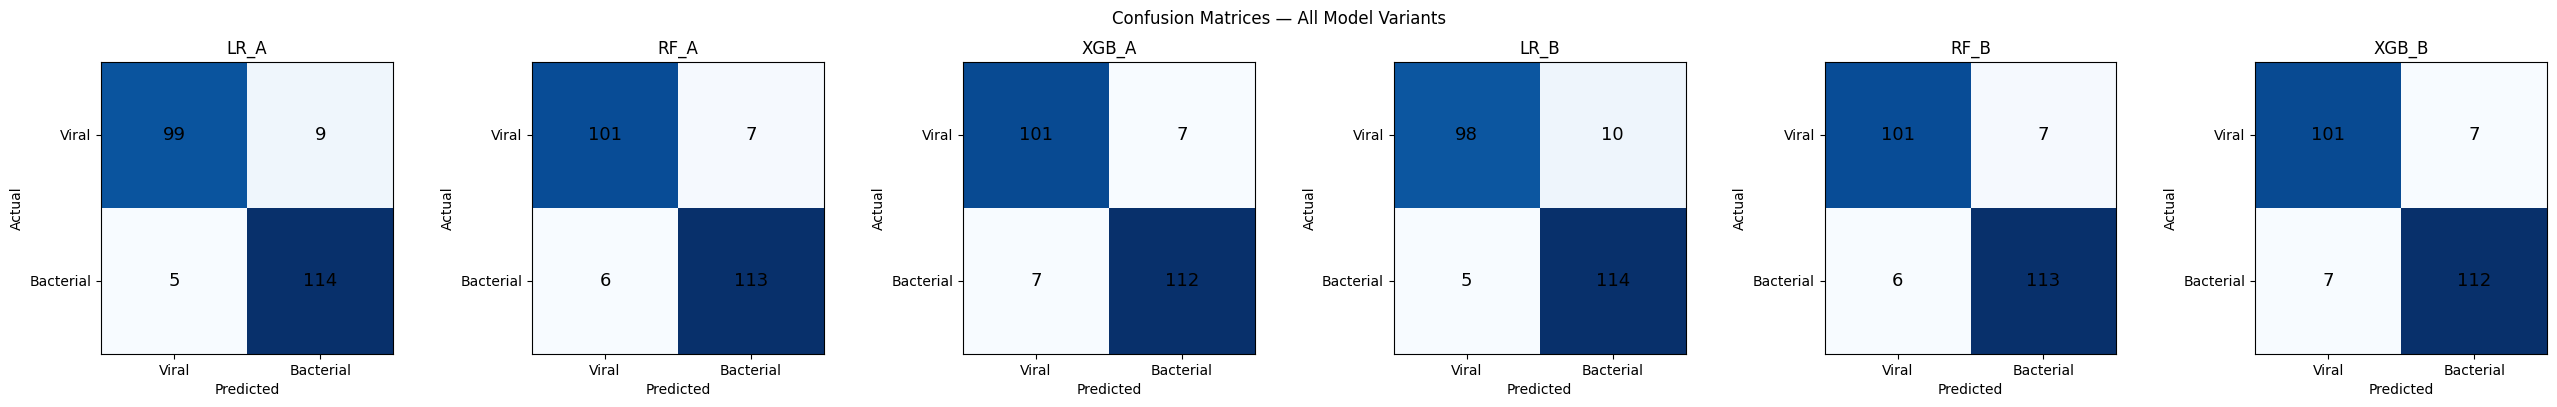

In [ ]:
# Plot confusion matrices for all 6 model variants
fig, axes = plt.subplots(1, 6, figsize=(26,4))
for ax, (name, model, X_test, y_test) in zip(axes, model_configs):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha="center", va="center", fontsize=13)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Viral","Bacterial"]); ax.set_yticklabels(["Viral","Bacterial"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(name)
plt.suptitle("Confusion Matrices — All Model Variants")
plt.tight_layout()
plt.savefig("MVB-06-figures/fig-03-confusion-matrices.png", dpi=150)
plt.show()

## Detailed Metrics — Bacterial-Class Focus

Per the project's evaluation priority, Bacterial-class recall (not aggregate accuracy) is the primary comparison metric.

In [ ]:

# Build a detailed metrics table focused on the Bacterial class
rows = []
for name, model, X_test, y_test in model_configs:
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    rows.append({
        "Model": name,
        "Bacterial_Recall": round(recall_score(y_test, preds), 4),
        "Bacterial_Precision": round(precision_score(y_test, preds), 4),
        "False_Negatives": fn, "False_Positives": fp, "TN": tn, "TP": tp,
    })

detail_df = pd.DataFrame(rows)
detail_df.to_csv("MVB-06-results/MVB-06-detailed-metrics.csv", index=False)
print(detail_df.to_string())

   Model  Bacterial_Recall  Bacterial_Precision  False_Negatives  False_Positives   TN   TP
0   LR_A            0.9580               0.9268                5                9   99  114
1   RF_A            0.9496               0.9417                6                7  101  113
2  XGB_A            0.9412               0.9412                7                7  101  112
3   LR_B            0.9580               0.9194                5               10   98  114
4   RF_B            0.9496               0.9417                6                7  101  113
5  XGB_B            0.9412               0.9412                7                7  101  112


**Finding:** Logistic Regression achieves the highest Bacterial recall (0.958, 5 false negatives) on both feature sets, outperforming Random Forest and XGBoost (0.950, 6 false negatives) on this specific metric — despite Random Forest/XGBoost showing higher ROC-AUC in Stage 05's baseline comparison. This demonstrates why model selection here follows the project's stated clinical priority (Bacterial recall) rather than aggregate performance: a selection based purely on ROC-AUC or accuracy would have chosen a model that misses more bacterial cases.

## False Negative Analysis

Examining the specific Bacterial cases missed by the selected model (Logistic Regression, Feature Set B) to understand what characterizes these errors.

In [ ]:

# Identify and examine the false negative cases for LR_B (the leading candidate model)
preds_lr_b = lr_b.predict(X_test_b_scaled)
X_test_b_labeled = X_test_b.copy()
X_test_b_labeled["Actual"] = y_test_b
X_test_b_labeled["Predicted"] = preds_lr_b

false_negatives = X_test_b_labeled[(X_test_b_labeled["Actual"]==1) & (X_test_b_labeled["Predicted"]==0)]
false_negatives.to_csv("MVB-06-results/MVB-06-false-negatives.csv", index=False)
print(f"Number of false negatives (LR_B): {len(false_negatives)}")
print(false_negatives)

Number of false negatives (LR_B): 5
     Age  Gender  WBC_Count  Protein_Level  Glucose_Level  Hemoglobin  \
320   68       0      18441            127             90          16   
268   28       0       4022             42             62          16   
126   89       0      12956             20            133          16   
600   88       0       2008             21            114          16   
417   78       0      18250            298            103          12   

     WBC_Blood_Count  Platelets  CRP_Level  Actual  Predicted  
320             8112     306984         14       1          0  
268             8127     379378         23       1          0  
126             9285     369973          4       1          0  
600             9479     345844         97       1          0  
417             4490     395261         68       1          0  


**Observation:** All 5 missed Bacterial cases share elevated Hemoglobin (12–16 g/dL) — consistent with the Viral profile (Stage 03 mean: 14.5) rather than the Bacterial profile (Stage 03 mean: 5.4). Two of the five also show unusually low `WBC_Count` for Bacterial cases (near the dataset's overall minimum). These are atypical presentations where blood markers resemble the Viral pattern despite the true diagnosis being Bacterial — the kind of borderline case a clinician would also find difficult, and precisely the scenario the project's Pre-Decision Verification Checkpoint concept is designed to flag for mandatory human review rather than autonomous model decision.

## Classification Reports — Leading Candidates

In [ ]:

# Full classification reports for the two Logistic Regression variants (the leading candidates on recall)
print("=== LR_A (Full) ===")
print(classification_report(y_test_a, lr_a.predict(X_test_a_scaled), target_names=["Viral","Bacterial"]))
print()
print("=== LR_B (Restricted) ===")
print(classification_report(y_test_b, lr_b.predict(X_test_b_scaled), target_names=["Viral","Bacterial"]))

=== LR_A (Full) ===
              precision    recall  f1-score   support

       Viral       0.95      0.92      0.93       108
   Bacterial       0.93      0.96      0.94       119

    accuracy                           0.94       227
   macro avg       0.94      0.94      0.94       227
weighted avg       0.94      0.94      0.94       227


=== LR_B (Restricted) ===
              precision    recall  f1-score   support

       Viral       0.95      0.91      0.93       108
   Bacterial       0.92      0.96      0.94       119

    accuracy                           0.93       227
   macro avg       0.94      0.93      0.93       227
weighted avg       0.93      0.93      0.93       227



## Final Model Selection

**Selection criterion:** Highest Bacterial recall with acceptable precision, per the project's clinical priority — not aggregate accuracy or ROC-AUC alone.

**Result:** LR_A and LR_B tie exactly on Bacterial recall (0.958, 5 false negatives each out of 119). LR_A has marginally higher precision (0.927 vs 0.919 — one fewer false positive across 227 test cases).

**Decision: Logistic Regression on Feature Set B (Restricted) — `LR_B` — is selected as the final model.**

**Justification:** The precision difference between LR_A and LR_B is negligible (less than one percentage point, a single false-positive case). Selecting LR_B avoids relying on `Pathogen_Present` — a feature identified in Stage 03 as a near-perfect proxy for the diagnosis label rather than a genuine independent predictor. This is a substantively stronger position for the project's Responsible AI framing and Model Card: the deployed model's performance is driven by genuine clinical biomarkers, not a variable that risks trivially reproducing the label. The marginal precision cost is a reasonable trade-off for this governance benefit.

## Summary

- All 6 model variants evaluated via ROC curves, precision-recall curves, confusion matrices, and Bacterial-class-focused metrics.
- Logistic Regression outperformed Random Forest/XGBoost on Bacterial recall (0.958 vs 0.950) despite lower ROC-AUC — confirming the value of selecting by the project's stated clinical priority rather than aggregate metrics.
- False negative analysis of the leading candidate (LR_B) found all 5 missed cases share a Viral-like Hemoglobin profile — atypical Bacterial presentations, not systematic model failure.
- Final model selected: **Logistic Regression, Feature Set B (Restricted)** — ties for best Bacterial recall while avoiding the `Pathogen_Present` proxy feature.

---

## Stage Status

**Stage:** Completed

**Primary Outputs Produced:**
✓ 3 figures (MVB-06-figures/): ROC curves, precision-recall curves, confusion matrices
✓ Detailed metrics table (MVB-06-detailed-metrics.csv)
✓ False negative case table (MVB-06-false-negatives.csv)
✓ Evaluation notebook
✓ Updated documentation

**Input for Next Stage:**
`Models/MVB-05-lr-B.pkl`, `Models/MVB-05-scaler-B.pkl` (final selected model)

**Next Stage:**
07_MVB_Explainability — SHAP analysis on the selected model (LR_B) to explain individual predictions and identify the most influential clinical features.

In [12]:
# Notebook completion timestamp and environment info
from datetime import datetime
import platform
import sklearn

print("="*60)
print("Stage 06 completed successfully")
print("Completion time:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Python:", platform.python_version())
print("Scikit-learn:", sklearn.__version__)
print("="*60)

Stage 06 completed successfully
Completion time: 2026-07-26 13:32:13
Python: 3.12.13
Scikit-learn: 1.6.1
